In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
data = pd.read_csv("../data/telco_customer_churn.csv")

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
from sklearn.model_selection import StratifiedShuffleSplit
split = StratifiedShuffleSplit(n_splits = 1, test_size = 0.2, random_state = 42)
for train_index, test_index in split.split(data, data["Churn"]):
    train_set = data.loc[train_index]
    test_set = data.loc[test_index]

In [5]:
train_set.info()

<class 'pandas.DataFrame'>
Index: 5634 entries, 3738 to 5639
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5634 non-null   str    
 1   gender            5634 non-null   str    
 2   SeniorCitizen     5634 non-null   int64  
 3   Partner           5634 non-null   str    
 4   Dependents        5634 non-null   str    
 5   tenure            5634 non-null   int64  
 6   PhoneService      5634 non-null   str    
 7   MultipleLines     5634 non-null   str    
 8   InternetService   5634 non-null   str    
 9   OnlineSecurity    5634 non-null   str    
 10  OnlineBackup      5634 non-null   str    
 11  DeviceProtection  5634 non-null   str    
 12  TechSupport       5634 non-null   str    
 13  StreamingTV       5634 non-null   str    
 14  StreamingMovies   5634 non-null   str    
 15  Contract          5634 non-null   str    
 16  PaperlessBilling  5634 non-null   str    
 17  PaymentM

In [6]:
test_set.info()

<class 'pandas.DataFrame'>
Index: 1409 entries, 437 to 5613
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        1409 non-null   str    
 1   gender            1409 non-null   str    
 2   SeniorCitizen     1409 non-null   int64  
 3   Partner           1409 non-null   str    
 4   Dependents        1409 non-null   str    
 5   tenure            1409 non-null   int64  
 6   PhoneService      1409 non-null   str    
 7   MultipleLines     1409 non-null   str    
 8   InternetService   1409 non-null   str    
 9   OnlineSecurity    1409 non-null   str    
 10  OnlineBackup      1409 non-null   str    
 11  DeviceProtection  1409 non-null   str    
 12  TechSupport       1409 non-null   str    
 13  StreamingTV       1409 non-null   str    
 14  StreamingMovies   1409 non-null   str    
 15  Contract          1409 non-null   str    
 16  PaperlessBilling  1409 non-null   str    
 17  PaymentMe

In [7]:
compare = pd.DataFrame({
    "FULL":data["Churn"].value_counts(normalize=True),
    "TRAIN":train_set["Churn"].value_counts(normalize=True),
    "TEST":test_set["Churn"].value_counts(normalize=True),
})
print(compare)

          FULL     TRAIN      TEST
Churn                             
No     0.73463  0.734647  0.734564
Yes    0.26537  0.265353  0.265436


In [8]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [9]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder

In [10]:
from sklearn.base import BaseEstimator, TransformerMixin

In [11]:
class StrToNum():
    def __init__(self):
        pass
    # fit method is needed so that the model can learn something from the data
    def fit(self, X, y = None):
        return self
    def transform(self, X, y = None):
        Y = X.copy()
        Y = Y.drop("customerID", axis = "columns")
        Y["TotalCharges"] = pd.to_numeric(Y["TotalCharges"], errors="coerce")
        return Y

In [12]:
class C_OneHotEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, columns):
        self.columns = columns

    # fit method is needed so that the model can learn something from the data
    def fit(self, X, y = None):
        self.fitted_ = True
        return self

    def transform(self, X, y = None):
        Y = X.copy()
        for column in self.columns:
            Y = pd.get_dummies(Y, columns = [column]);
            if column + "_No internet service" in Y:
                Y = Y.drop(column + "_No internet service", axis = "columns")
        return Y

In [13]:
columns = ["gender", "Partner", "Dependents", "PaperlessBilling", "PaymentMethod", "PhoneService", "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]
pipeline = Pipeline([
    ("to_num", StrToNum()),
    ("one_hot", C_OneHotEncoder(columns)),
])

In [14]:
train_copy = train_set.copy()

In [15]:
pipeline.fit(train_copy)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('to_num', ...), ('one_hot', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,columns,"['gender', 'Partner', ...]"


In [16]:
new_train = pipeline.transform(train_copy)

In [17]:
#ord_enc = encoder.named_transformers_["ordinal"]
#column_names = encoder.get_feature_names_out()
#print(ord_enc.categories_)

In [18]:
#new_train = pd.DataFrame(data = new_train, columns=column_names)

In [19]:
new_train.info()

<class 'pandas.DataFrame'>
Index: 5634 entries, 3738 to 5639
Data columns (total 38 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   SeniorCitizen                            5634 non-null   int64  
 1   tenure                                   5634 non-null   int64  
 2   Contract                                 5634 non-null   str    
 3   MonthlyCharges                           5634 non-null   float64
 4   TotalCharges                             5626 non-null   float64
 5   Churn                                    5634 non-null   str    
 6   gender_Female                            5634 non-null   bool   
 7   gender_Male                              5634 non-null   bool   
 8   Partner_No                               5634 non-null   bool   
 9   Partner_Yes                              5634 non-null   bool   
 10  Dependents_No                            5634 non-null   bool

In [20]:
pd.crosstab(new_train["InternetService_DSL"], new_train["Churn"])

Churn,No,Yes
InternetService_DSL,,
False,2564,1133
True,1575,362


In [21]:
from scipy.stats import chi2_contingency

In [22]:
alpha = 0.05
result = {}
n_columns = ["InternetService_DSL", "InternetService_Fiber optic", "InternetService_No",
             "gender_Male", "gender_Female", "MultipleLines_No phone service",
             "PaymentMethod_Bank transfer (automatic)", "PaymentMethod_Credit card (automatic)",
             "PaymentMethod_Electronic check", "PaymentMethod_Mailed check"]

m_columns = ["Partner", "PaperlessBilling", "Dependents", 
             "PhoneService", "MultipleLines", "OnlineSecurity",
             "OnlineBackup", "DeviceProtection", "TechSupport",
             "StreamingTV", "StreamingMovies"]

values = ["_Yes", "_No"]

def cal_chi2(x, y, alpha, df):
    table = pd.crosstab(df[x], df[y])
    chi2_stat, p_value, _, _ = chi2_contingency(table)
    N = len(df)
    cramers_v = np.sqrt(chi2_stat/N*(min(table.shape) - 1))

    decision = "Reject Null Hypothesis(Keep Feature)" if p_value < alpha else "Accept Null Hypothesis (Drop Feature)"
    result[x] = {
        'chi2_stat':chi2_stat,
        'p_value': p_value,
        'decision':decision,
        'cramers_v':cramers_v
    }

for column in n_columns:
    cal_chi2(column, "Churn", alpha, new_train);
    
for column in m_columns:
    for value in values:
        t_column = column + value
        cal_chi2(t_column, "Churn", alpha, new_train);
        
chi2_df = pd.DataFrame(result).T # .T transposes the dataframe
chi2_df = chi2_df.sort_values(by = "p_value")
chi2_df



,chi2_stat,p_value,decision,cramers_v
OnlineSecurity_No,674.402324,0.0,Reject Null Hypothesis(Keep Feature),0.34598
TechSupport_No,646.317096,0.0,Reject Null Hypothesis(Keep Feature),0.338699
InternetService_Fiber optic,549.320549,0.0,Reject Null Hypothesis(Keep Feature),0.312251
PaymentMethod_Electronic check,537.203154,0.0,Reject Null Hypothesis(Keep Feature),0.308788
OnlineBackup_No,407.466552,0.0,Reject Null Hypothesis(Keep Feature),0.268929
DeviceProtection_No,347.454,0.0,Reject Null Hypothesis(Keep Feature),0.248336
InternetService_No,294.010532,0.0,Reject Null Hypothesis(Keep Feature),0.22844
PaperlessBilling_Yes,219.922454,0.0,Reject Null Hypothesis(Keep Feature),0.197572
PaperlessBilling_No,219.922454,0.0,Reject Null Hypothesis(Keep Feature),0.197572
OnlineSecurity_Yes,170.844194,0.0,Reject Null Hypothesis(Keep Feature),0.174137


In [23]:
new_train.head(10)

,SeniorCitizen,tenure,Contract,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male,Partner_No,Partner_Yes,...,OnlineBackup_No,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_Yes,TechSupport_No,TechSupport_Yes,StreamingTV_No,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_Yes
3738,0,35,Month-to-month,49.20,1701.65,No,False,True,True,False,...,True,False,False,True,True,False,False,True,False,True
3151,0,15,Month-to-month,75.10,1151.55,No,False,True,False,True,...,True,False,True,False,True,False,True,False,True,False
4860,0,13,Two year,40.55,590.35,No,False,True,False,True,...,False,True,True,False,False,True,True,False,True,False
3867,0,26,Two year,73.50,1905.70,No,True,False,False,True,...,False,True,False,True,True,False,False,True,False,True
3810,0,1,Month-to-month,44.55,44.55,No,False,True,False,True,...,True,False,True,False,True,False,True,False,True,False
2666,0,66,Two year,79.50,5196.10,No,False,True,True,False,...,False,True,False,True,False,True,False,True,False,True
2645,0,1,Month-to-month,19.80,19.80,No,True,False,True,False,...,False,False,False,False,False,False,False,False,False,False
189,0,40,Month-to-month,56.60,2379.10,No,True,False,False,True,...,False,True,True,False,True,False,True,False,True,False
5767,0,65,Two year,59.80,3808.20,No,True,False,False,True,...,True,False,True,False,False,True,False,True,True,False
2257,0,60,One year,80.55,4847.05,No,True,False,True,False,...,True,False,False,True,False,True,False,True,False,True


In [24]:
new_train['SeniorCitizen'].value_counts()

SeniorCitizen
0    4714
1     920
Name: count, dtype: int64

In [25]:
def showCategories(data):
    data = data.copy()
    table = {
        "Column":[],
        "Num Categories":[],
        "Categories":[],
    }
    cat_col = data.select_dtypes(include="str").columns
    for col in cat_col:
        if col == "customerID":
            continue
        print(col)
        values = data[col].dropna().unique()
        
        table["Column"].append(col)
        table["Num Categories"].append(len(values))
        table["Categories"].append(values)

    cat_col1 = data.select_dtypes(include="bool").columns
    for col in cat_col1:
        value = data[col].dropna().unique()
        table["Column"].append(col)
        table["Num Categories"].append(len(values))
        table["Categories"].append(values)

    pd.set_option("display.max_colwidth", None)
    return pd.DataFrame(table)

showCategories(new_train)

Contract
Churn


,Column,Num Categories,Categories
0,Contract,3,"[Month-to-month, Two year, One year]"
1,Churn,2,"[No, Yes]"
2,gender_Female,2,"[No, Yes]"
3,gender_Male,2,"[No, Yes]"
4,Partner_No,2,"[No, Yes]"
5,Partner_Yes,2,"[No, Yes]"
6,Dependents_No,2,"[No, Yes]"
7,Dependents_Yes,2,"[No, Yes]"
8,PaperlessBilling_No,2,"[No, Yes]"
9,PaperlessBilling_Yes,2,"[No, Yes]"


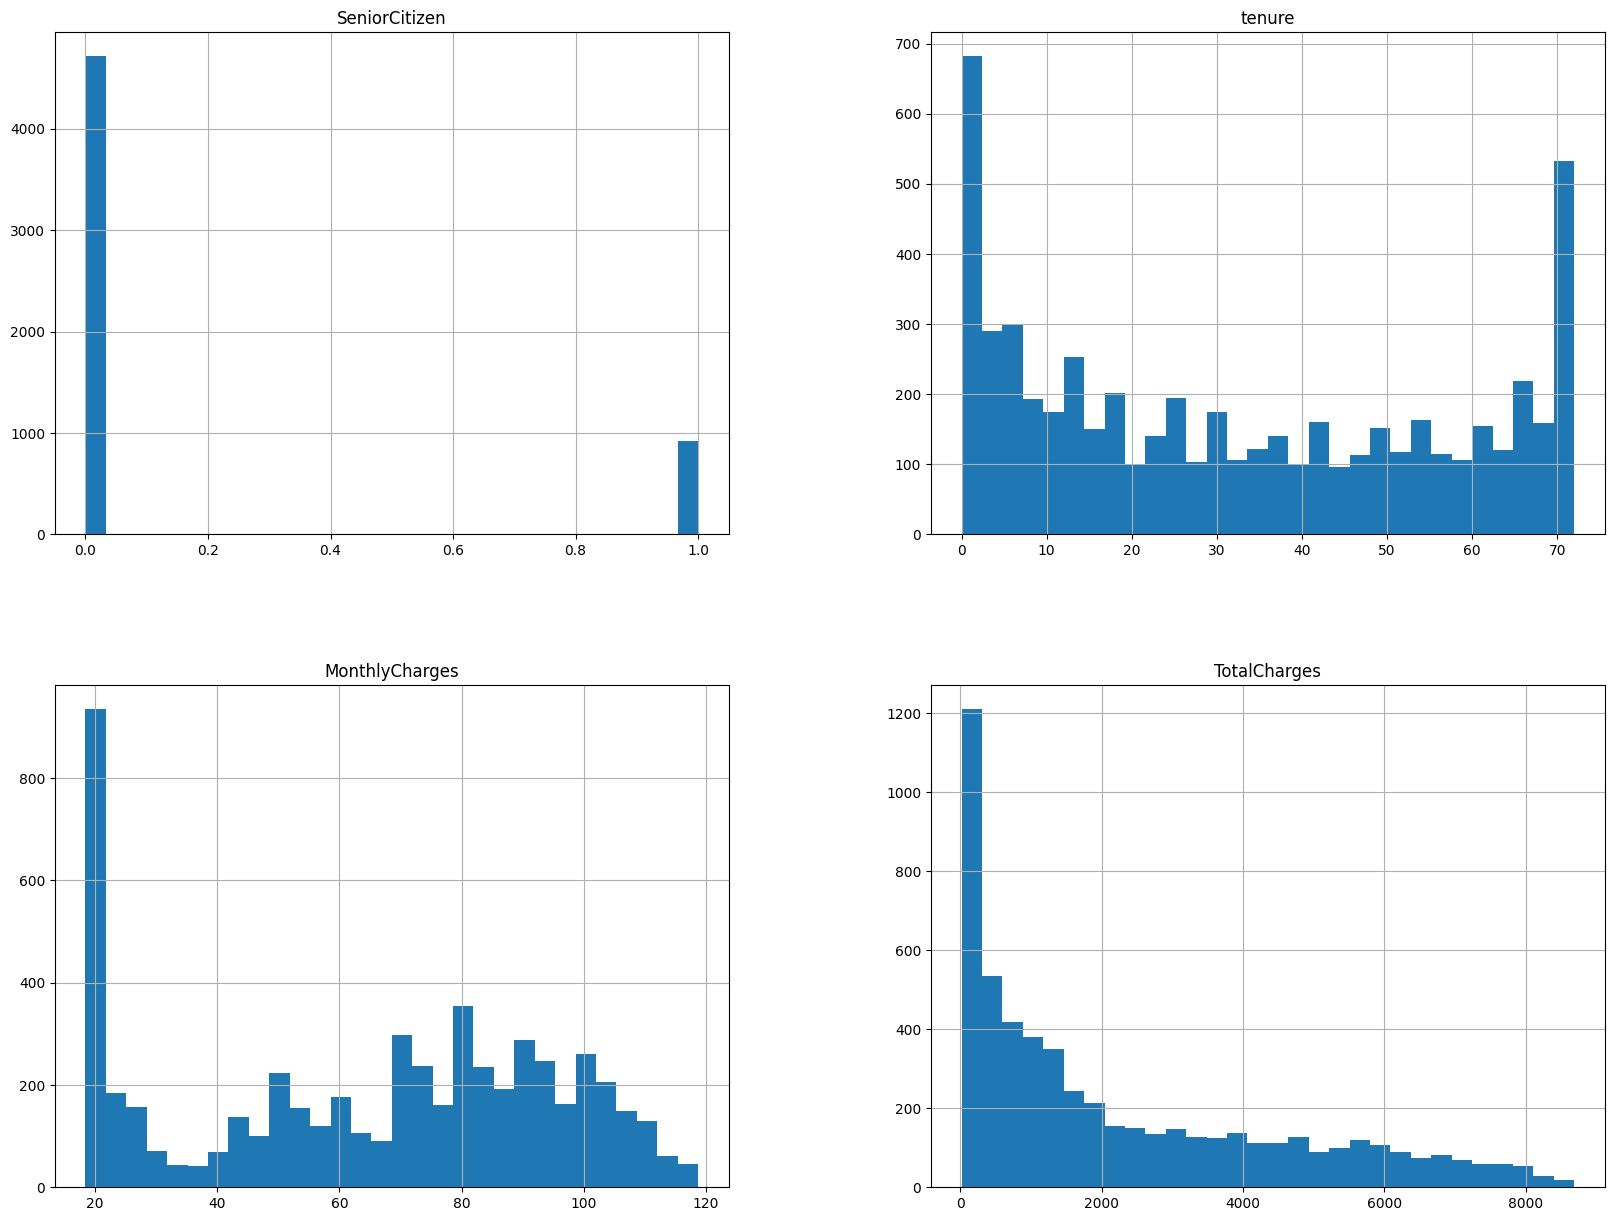

In [26]:
x = new_train.hist(bins = 30, figsize = (20,15))

In [27]:
new_train["tenure"].describe()

count    5634.000000
mean       32.485091
std        24.568744
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64